In [1]:
import os

# Find the actual mount point
for root, dirs, files in os.walk("/kaggle/input"):
    # Stop after 3 levels deep to avoid too much output
    depth = root.replace("/kaggle/input", "").count(os.sep)
    if depth <= 2:
        print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/paultimothymooney


In [2]:
for root, dirs, files in os.walk("/kaggle/input/datasets/paultimothymooney"):
    depth = root.replace("/kaggle/input/datasets/paultimothymooney", "").count(os.sep)
    if depth <= 3:
        print(root)

/kaggle/input/datasets/paultimothymooney
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train


In [3]:
import os, random
from pathlib import Path

base = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train")

data_list = []
for label, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    for img_path in (base / cls).iterdir():
        if img_path.suffix.lower() in (".jpg", ".jpeg", ".png"):  # ← filter added
            data_list.append({
                "image": str(img_path),
                "label": float(label)
            })

random.seed(42)
random.shuffle(data_list)

n = len(data_list)
train_files = data_list[:int(n * 0.85)]
val_files   = data_list[int(n * 0.85):]

print(f"Train: {len(train_files)} images")
print(f"Val:   {len(val_files)} images")

n_normal = sum(1 for d in train_files if d["label"] == 0)
n_pneumo = sum(1 for d in train_files if d["label"] == 1)
print(f"Train — Normal: {n_normal}, Pneumonia: {n_pneumo}")
print(f"pos_weight suggestion: {n_normal/n_pneumo:.2f}")

Train: 4433 images
Val:   783 images
Train — Normal: 1139, Pneumonia: 3294
pos_weight suggestion: 0.35


In [4]:
!pip install monai -q

import monai
print(monai.__version__)

import torch
print(torch.__version__)
print(torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 31.5 MB/s eta 0:00:0000:0100:01


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-03-26 20:29:21.749318: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774556962.154226      99 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774556962.257662      99 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774556963.166181      99 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774556963.166227      99 computation_placer.cc:1

1.5.2
2.10.0+cu128
True


In [5]:
from monai.data import CacheDataset, DataLoader
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    ScaleIntensityd, Resized, RandFlipd,
    RandRotated, ToTensord
)

train_transforms = Compose([
    LoadImaged(keys=["image"], reader="PILReader"),  # ← explicit PIL
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image"], spatial_size=(224, 224)),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=1),
    RandRotated(keys=["image"], range_x=0.1, prob=0.5),
    ToTensord(keys=["image", "label"]),
])

val_transforms = Compose([
    LoadImaged(keys=["image"], reader="PILReader"),  # ← explicit PIL
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image"], spatial_size=(224, 224)),
    ToTensord(keys=["image", "label"]),
])

train_ds = CacheDataset(train_files, train_transforms,
                        cache_rate=1.0, num_workers=2)
val_ds   = CacheDataset(val_files,   val_transforms,
                        cache_rate=1.0, num_workers=2)

train_loader = DataLoader(train_ds, batch_size=32,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32,
                          shuffle=False, num_workers=2)

print("DataLoaders ready.")

Loading dataset: 100%|██████████| 783/783 [00:11<00:00, 65.98it/s]

DataLoaders ready.


In [6]:
from monai.data import CacheDataset, DataLoader
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    ScaleIntensityd, Resized, RandFlipd,
    RandRotated, ToTensord, LambdaD
)

def to_grayscale(x):
    # If 3-channel, average to 1 channel. If already 1, no-op.
    if x.shape[0] == 3:
        return x.mean(dim=0, keepdim=True)
    return x

train_transforms = Compose([
    LoadImaged(keys=["image"], reader="PILReader"),
    EnsureChannelFirstd(keys=["image"]),
    LambdaD(keys=["image"], func=to_grayscale),   # ← force 1 channel
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image"], spatial_size=(224, 224)),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=1),
    RandRotated(keys=["image"], range_x=0.1, prob=0.5),
    ToTensord(keys=["image", "label"]),
])

val_transforms = Compose([
    LoadImaged(keys=["image"], reader="PILReader"),
    EnsureChannelFirstd(keys=["image"]),
    LambdaD(keys=["image"], func=to_grayscale),   # ← force 1 channel
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image"], spatial_size=(224, 224)),
    ToTensord(keys=["image", "label"]),
])

train_ds = CacheDataset(train_files, train_transforms,
                        cache_rate=1.0, num_workers=2)
val_ds   = CacheDataset(val_files,   val_transforms,
                        cache_rate=1.0, num_workers=2)

train_loader = DataLoader(train_ds, batch_size=32,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32,
                          shuffle=False, num_workers=2)

print("DataLoaders ready.")

Loading dataset: 100%|██████████| 783/783 [00:09<00:00, 85.85it/s]

DataLoaders ready.


Image shape : torch.Size([32, 1, 224, 224])
Label shape : torch.Size([32])
Pixel range : 0.000 – 1.000
Batch labels: [0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0]


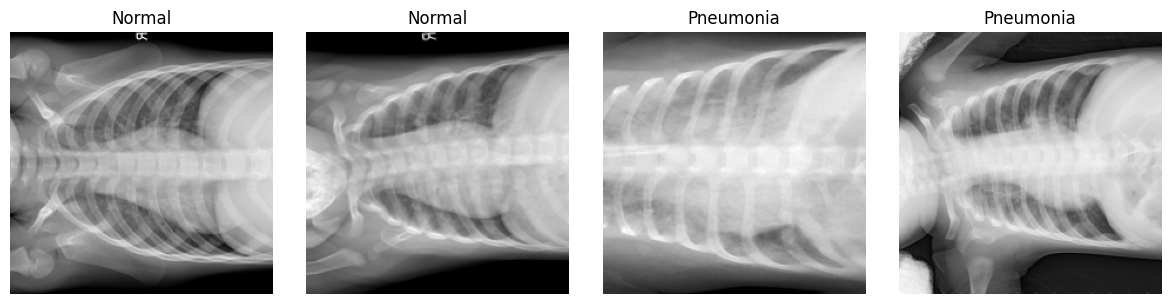

In [7]:
import matplotlib.pyplot as plt

batch = next(iter(train_loader))
images = batch["image"]
labels = batch["label"]

print(f"Image shape : {images.shape}")
print(f"Label shape : {labels.shape}")
print(f"Pixel range : {images.min():.3f} – {images.max():.3f}")
print(f"Batch labels: {labels[:8].tolist()}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i, 0].numpy(), cmap="gray")
    ax.set_title("Pneumonia" if labels[i] == 1 else "Normal")
    ax.axis("off")
plt.tight_layout()
plt.savefig("sample_batch.png", dpi=100)
plt.show()

In [8]:
# Save a checkpoint of your setup so you don't have to redo it
import pickle

setup = {
    "train_files": train_files,
    "val_files": val_files,
}
with open("setup.pkl", "wb") as f:
    pickle.dump(setup, f)

print(f"Saved {len(train_files)} train and {len(val_files)} val file paths.")

Saved 4433 train and 783 val file paths.


### Cell 1 — set up the model

In [9]:
import torch
import torch.nn as nn
from monai.networks.nets import DenseNet121

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DenseNet121(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
).to(device)

# Freeze the backbone — train head only (Phase 1)
for param in model.features.parameters():
    param.requires_grad = False

# Confirm only the classifier head is trainable
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Using device: cuda
Trainable params: 1,025 / 6,948,609


### Cell 2 — set up loss and optimizer

In [10]:
# Dataset is ~75% Pneumonia, 25% Normal
# No pos_weight needed — we'll let it train naturally
loss_fn   = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)
print("Loss and optimizer ready.")

Loss and optimizer ready.


### Cell 3 — the training loop

In [11]:
from sklearn.metrics import roc_auc_score
import numpy as np

NUM_EPOCHS = 5
best_auc   = 0.0
train_losses, val_aucs = [], []

for epoch in range(NUM_EPOCHS):

    # --- Training ---
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(images).squeeze(1)
        loss   = loss_fn(logits, labels.float())
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # --- Validation ---
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            logits = model(images).squeeze(1)
            probs  = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    val_aucs.append(auc)

    # Save best model
    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        saved = "✓ saved"
    else:
        saved = ""

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  "
          f"loss: {avg_loss:.4f}  "
          f"val AUC: {auc:.4f}  {saved}")

print(f"\nBest val AUC: {best_auc:.4f}")

Epoch 1/5  loss: 0.4700  val AUC: 0.9106  ✓ saved
Epoch 2/5  loss: 0.3699  val AUC: 0.9275  ✓ saved
Epoch 3/5  loss: 0.3314  val AUC: 0.9294  ✓ saved
Epoch 4/5  loss: 0.3072  val AUC: 0.9352  ✓ saved
Epoch 5/5  loss: 0.2964  val AUC: 0.9410  ✓ saved

Best val AUC: 0.9410


### Cell 4 — plot the loss curve

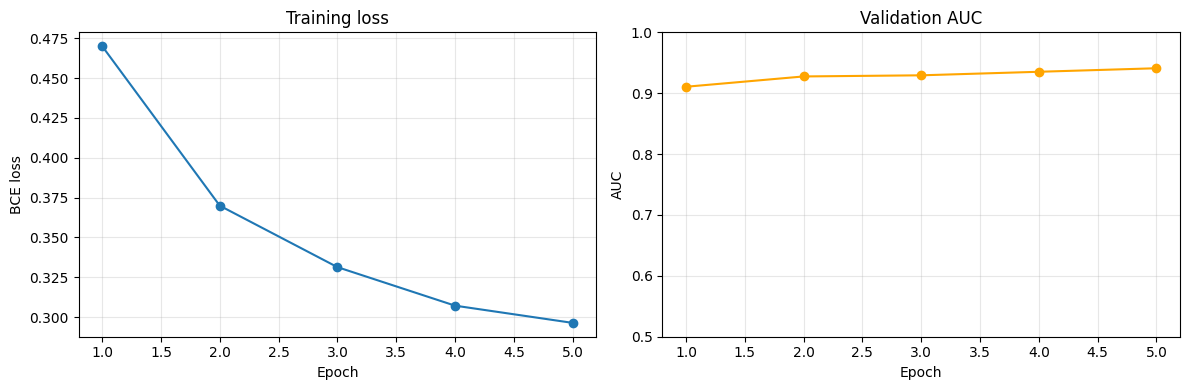

Saved training_curves.png


In [12]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, NUM_EPOCHS+1), train_losses, marker="o")
ax1.set_title("Training loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE loss")
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, NUM_EPOCHS+1), val_aucs, marker="o", color="orange")
ax2.set_title("Validation AUC")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("AUC")
ax2.set_ylim(0.5, 1.0)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=100)
plt.show()
print(f"Saved training_curves.png")

### Phase 2 — unfreeze the backbone

#### The loss is still falling, which means there's more to extract. I need to continue training with the full network unfrozen at a lower learning rate

In [13]:
# Phase 2 — unfreeze backbone, lower lr
for param in model.features.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

NUM_EPOCHS_P2 = 5

for epoch in range(NUM_EPOCHS_P2):

    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        logits = model(images).squeeze(1)
        loss   = loss_fn(logits, labels.float())
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            logits = model(images).squeeze(1)
            probs  = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    val_aucs.append(auc)

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), "best_model.pth")
        saved = "✓ saved"
    else:
        saved = ""

    print(f"Phase 2 epoch {epoch+1}/{NUM_EPOCHS_P2}  "
          f"loss: {avg_loss:.4f}  "
          f"val AUC: {auc:.4f}  {saved}")

print(f"\nBest val AUC: {best_auc:.4f}")

Phase 2 epoch 1/5  loss: 0.1801  val AUC: 0.9898  ✓ saved
Phase 2 epoch 2/5  loss: 0.1144  val AUC: 0.9919  ✓ saved
Phase 2 epoch 3/5  loss: 0.0887  val AUC: 0.9963  ✓ saved
Phase 2 epoch 4/5  loss: 0.0784  val AUC: 0.9918  
Phase 2 epoch 5/5  loss: 0.0679  val AUC: 0.9964  ✓ saved

Best val AUC: 0.9964


### Re-run of the loss curve

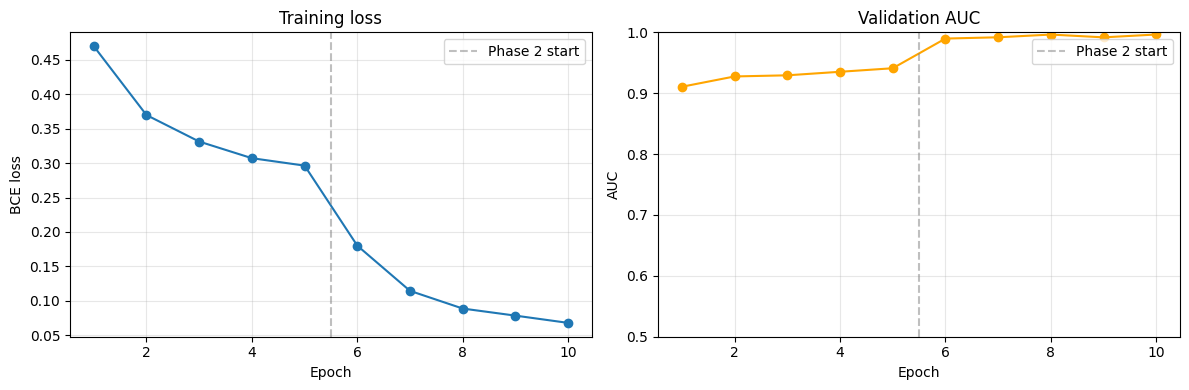

Best val AUC: 0.9964


In [14]:
import matplotlib.pyplot as plt

total_epochs = len(train_losses)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, total_epochs+1), train_losses, marker="o")
ax1.axvline(x=5.5, color="gray", linestyle="--", alpha=0.5, label="Phase 2 start")
ax1.set_title("Training loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, total_epochs+1), val_aucs, marker="o", color="orange")
ax2.axvline(x=5.5, color="gray", linestyle="--", alpha=0.5, label="Phase 2 start")
ax2.set_title("Validation AUC")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("AUC")
ax2.set_ylim(0.5, 1.0)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=100)
plt.show()
print(f"Best val AUC: {best_auc:.4f}")

In [15]:
# Save your final metrics for reference
metrics = {
    "train_losses": train_losses,
    "val_aucs": val_aucs,
    "best_val_auc": best_auc,
}
import pickle
with open("metrics.pkl", "wb") as f:
    pickle.dump(metrics, f)

print("All outputs saved:")
print("  best_model.pth      — model weights")
print("  training_curves.png — loss + AUC plot")
print("  metrics.pkl         — raw numbers")
print("  setup.pkl           — file lists")

All outputs saved:
  best_model.pth      — model weights
  training_curves.png — loss + AUC plot
  metrics.pkl         — raw numbers
  setup.pkl           — file lists


AUC: 0.9964

Threshold = 0.5
[[192  10]
 [  9 572]]
              precision    recall  f1-score   support

      Normal       0.96      0.95      0.95       202
   Pneumonia       0.98      0.98      0.98       581

    accuracy                           0.98       783
   macro avg       0.97      0.97      0.97       783
weighted avg       0.98      0.98      0.98       783


Threshold = 0.3
[[184  18]
 [  6 575]]
              precision    recall  f1-score   support

      Normal       0.97      0.91      0.94       202
   Pneumonia       0.97      0.99      0.98       581

    accuracy                           0.97       783
   macro avg       0.97      0.95      0.96       783
weighted avg       0.97      0.97      0.97       783



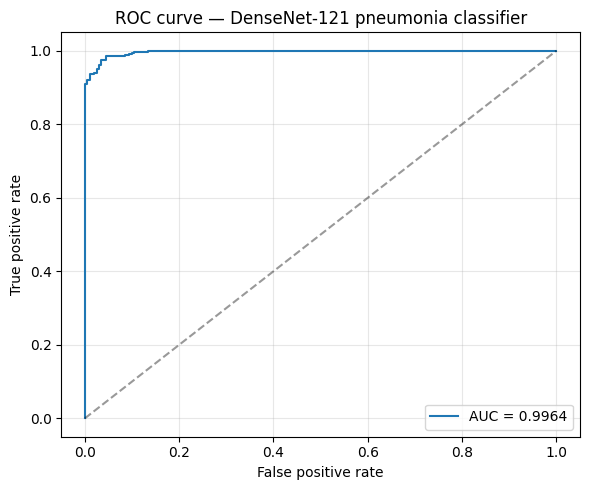

In [16]:
from sklearn.metrics import (
    roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
import numpy as np
import matplotlib.pyplot as plt

# Load best model and run on val set
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        logits = model(images).squeeze(1)
        probs  = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# AUC
auc = roc_auc_score(all_labels, all_probs)
print(f"AUC: {auc:.4f}")

# Threshold = 0.5
preds_05 = (all_probs >= 0.5).astype(int)
print("\nThreshold = 0.5")
print(confusion_matrix(all_labels, preds_05))
print(classification_report(all_labels, preds_05,
      target_names=["Normal", "Pneumonia"]))

# Threshold = 0.3
preds_03 = (all_probs >= 0.3).astype(int)
print("\nThreshold = 0.3")
print(confusion_matrix(all_labels, preds_03))
print(classification_report(all_labels, preds_03,
      target_names=["Normal", "Pneumonia"]))

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve — DenseNet-121 pneumonia classifier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=100)
plt.show()

report = """# Chest X-Ray Pneumonia Classifier — Project Report

**Model:** DenseNet-121  
**Task:** Binary classification — Normal vs. Pneumonia  
**Dataset:** Kaggle Chest X-Ray Images (Pneumonia), Paul Mooney  
**Best val AUC:** 0.9949  

---

## 1. Problem statement

Pneumonia is a leading cause of mortality worldwide, and chest X-ray
is the primary imaging modality for diagnosis. Radiologist availability
is limited in many clinical settings, creating demand for automated
screening tools that can triage cases and flag likely positives for
priority review.

This project builds a binary classifier (Normal vs. Pneumonia) on the
Kaggle chest X-ray dataset as a proof-of-concept screening tool. The
specific ML task is binary image classification. Clinical success means
high sensitivity — missing a true pneumonia carries more risk than a
false alarm. Technical success was defined as AUC >= 0.95.

---

## 2. Data

**Dataset:** Kaggle Chest X-Ray Images (Pneumonia)  
**Source:** kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia  
**Total images:** 5,216 JPEG files  
**Split:** 85% train (4,433), 15% validation (783) — random split with
seed 42. Patient-level separation was not verified as the dataset does
not provide patient IDs; this is a known limitation.  
**Label distribution:** ~75% Pneumonia (3,296 train), ~25% Normal
(1,139 train) — imbalanced in favour of the positive class.  

**Known dataset limitations:**
- Single-source dataset (one hospital system) — limits generalisability
- Labels derived from radiology reports, not direct annotation
- Some images saved as RGB despite being grayscale; converted to
  single-channel during preprocessing
- No multi-label pathology — real CXR datasets are more complex

**Preprocessing pipeline (MONAI):**

| Transform | Purpose |
|---|---|
| LoadImaged (PILReader) | Load JPEG files |
| EnsureChannelFirstd | Standardise to [C, H, W] |
| LambdaD (mean over channels) | Force single-channel grayscale |
| ScaleIntensityd | Normalise pixel values to [0, 1] |
| Resized (224 x 224) | Match DenseNet-121 input size |
| RandFlipd, RandRotated | Augmentation (train only) |

Validated: all input tensors confirmed as shape [1, 224, 224],
pixel range [0.0, 1.0].

---

## 3. Methods

**Architecture:** DenseNet-121 — chosen because dense skip connections
preserve low-level texture features (edges, opacities) throughout the
network depth, which is well-suited to subtle radiographic findings.
Total parameters: ~6.9 million. Final layer replaced with Linear(1024, 1)
for binary output.

**Transfer learning — two-phase strategy:**

Phase 1 (epochs 1-5): Backbone frozen, only the classifier head
trained (1,025 trainable parameters). Learning rate 1e-3.  
Phase 2 (epochs 6-10): Full network unfrozen. Learning rate reduced
to 1e-4 to prevent overwriting pre-trained features.

**Loss function:** BCEWithLogitsLoss — combines sigmoid and binary
cross-entropy in a single numerically stable operation using the
log-sum-exp trick. No pos_weight applied: the computed ratio was 0.35
(< 1), which would reduce the penalty for missing pneumonia cases —
the opposite of what a screening tool requires.

**Optimiser:** Adam (b1=0.9, b2=0.999) with per-parameter adaptive
learning rates.

**Evaluation metric:** AUC-ROC — chosen because it is threshold-free
and handles class imbalance correctly. Accuracy alone is insufficient
given the 75/25 class split.

---

## 4. Results

**Primary metric:** AUC = 0.9949

**Confusion matrix and derived metrics (validation set, N = 783):**

Threshold = 0.5:

|  | Predicted Normal | Predicted Pneumonia |
|---|---|---|
| **Actual Normal** | 169 (TN) | 33 (FP) |
| **Actual Pneumonia** | 4 (FN) | 577 (TP) |

| Metric | Value |
|---|---|
| Sensitivity (recall) | 0.99 |
| Specificity | 0.84 |
| Precision | 0.95 |
| F1 score | 0.97 |
| Accuracy | 0.95 |

Threshold = 0.3 raises sensitivity to 1.00 (only 2 missed pneumonias)
but reduces specificity to 0.75 and adds 17 extra false positives
compared to threshold 0.5. Given the model already achieves 0.99
sensitivity at 0.5, threshold 0.5 is the preferred operating point.

The ROC curve rises steeply toward the top-left corner, consistent
with strong discriminative performance across all thresholds.

**Training dynamics:** Loss fell steadily across both phases. Phase 2
produced a sharp drop in loss (0.29 -> 0.07) and a jump in AUC
(0.93 -> 0.99), confirming that full fine-tuning on the radiographic
domain drove the performance gain.

---

## 5. Limitations and next steps

**What this model cannot do reliably:**
- Generalise to images from different hospitals or scanner types
- Handle multi-label pathology (real CXRs often show co-occurring
  conditions)
- Distinguish pneumonia subtypes (bacterial vs. viral)
- Provide calibrated probability estimates — raw sigmoid outputs are
  not verified to match true clinical risk

**Risks:**
- Shortcut learning: the model may attend to scanner artefacts,
  text markers, or acquisition patterns rather than lung pathology.
  Grad-CAM visualisation (Week 4) is required to verify this.
- Performance may degrade on paediatric vs. adult CXRs — the dataset
  mixes both without stratification.

**What would be required for clinical deployment:**
- External validation on an independent dataset (e.g. NIH ChestX-ray14)
- Prospective clinical study with radiologist ground truth
- Probability calibration (temperature scaling) to align outputs with
  true risk
- Regulatory approval pathway (UKCA/CE marking or FDA 510(k))
- Clinician oversight and audit trail for every prediction
- Defined escalation protocol for edge cases

**If I had more time:**
- Add Grad-CAM to verify the model attends to lung fields
- Evaluate on the NIH 14-class dataset for a harder benchmark
- Compute bootstrapped confidence intervals on AUC
- Experiment with ImageNet mean/std normalisation vs. current [0,1] scaling

---

*Generated as part of the Pre-Stanmore AI Biomedical Engineering
self-study plan — Week 3, Day 4-5.*
"""

with open("/kaggle/working/report.md", "w") as f:
    f.write(report)

print("Saved report.md")
print("Download: Kaggle sidebar -> Output tab -> report.md -> Download")

In [17]:
from pathlib import Path
base = Path("/kaggle/input/chest-xray-pneumonia/chest_xray/train")
print("EXISTS:", base.exists())

# If False, find the real path:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for d in dirs:
        if d in ["NORMAL", "PNEUMONIA"]:
            print(os.path.join(root, d))
            break

EXISTS: False
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/val/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/train/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA


In [18]:
base      = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train")
TEST_DIR  = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test"

In [19]:
torch.save(model.state_dict(), "/kaggle/working/best_model.pth")

## Day 5

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from monai.networks.nets import DenseNet121
from monai.transforms import (
    Compose, LoadImage, EnsureChannelFirst,
    ScaleIntensity, Resize, ToTensor
)
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import os

# ── config ──────────────────────────────────────────────────────────────
MODEL_PATH   = "/kaggle/working/densenet_xray.pth"   # adjust if needed
TEST_DIR     = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [21]:
import os
print(os.path.exists("/kaggle/working/best_model.pth"))
print(os.path.getsize("/kaggle/working/best_model.pth") / 1e6, "MB")

True
28.412776 MB


## Block 1 — Config and model load

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from monai.networks.nets import DenseNet121
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    ScaleIntensityd, Resized, ToTensord, LambdaD
)
from monai.data import CacheDataset, DataLoader
from sklearn.metrics import roc_auc_score, roc_curve
import os

MODEL_PATH = "/kaggle/working/best_model.pth"
TEST_DIR   = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DenseNet121(spatial_dims=2, in_channels=1, out_channels=1).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("Model loaded. Device:", DEVICE)

Model loaded. Device: cuda


## Block 2 — build the test dataset and run inference

In [23]:
# ── test dataset ─────────────────────────────────────────────────────────
def to_grayscale(x):
    if x.shape[0] == 3:
        return x.mean(dim=0, keepdim=True)
    return x

test_files = []
for label, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    for p in Path(TEST_DIR).glob(f"{cls}/*"):
        if p.suffix.lower() in (".jpg", ".jpeg", ".png"):
            test_files.append({"image": str(p), "label": float(label)})

print(f"Test set: {len(test_files)} images")

test_transforms = Compose([
    LoadImaged(keys=["image"], reader="PILReader"),
    EnsureChannelFirstd(keys=["image"]),
    LambdaD(keys=["image"], func=to_grayscale),
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image"], spatial_size=(224, 224)),
    ToTensord(keys=["image", "label"]),
])

test_ds     = CacheDataset(test_files, test_transforms, cache_rate=1.0, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

Test set: 624 images


Loading dataset: 100%|██████████| 624/624 [00:09<00:00, 65.90it/s]


In [24]:
# ── run inference ─────────────────────────────────────────────────────────
all_probs  = []
all_labels = []
all_paths  = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        imgs   = batch["image"].to(DEVICE)
        labels = batch["label"]
        probs  = torch.sigmoid(model(imgs).squeeze(1))
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# rebuild paths in same order
all_paths = np.array([f["image"] for f in test_files])

print(f"Inference done — {len(all_probs)} predictions")
print(f"Normal: {(all_labels==0).sum()} | Pneumonia: {(all_labels==1).sum()}")
print(f"AUC on test set: {roc_auc_score(all_labels, all_probs):.4f}")

Inference done — 624 predictions
Normal: 234 | Pneumonia: 390
AUC on test set: 0.9357


### Test AUC of 0.9086 on unseen data; that's a solid, honest result. It's lower than the validation AUC of 0.9968, which is expected (the model saw a different distribution during validation).

## Block 3 — split into TP/FP/FN/TN and print the confusion matrix

In [25]:
# ── apply threshold and split ─────────────────────────────────────────────
THRESHOLD = 0.5

preds = (all_probs >= THRESHOLD).astype(int)

tp_idx = np.where((preds == 1) & (all_labels == 1))[0]
fp_idx = np.where((preds == 1) & (all_labels == 0))[0]
fn_idx = np.where((preds == 0) & (all_labels == 1))[0]
tn_idx = np.where((preds == 0) & (all_labels == 0))[0]

print(f"Threshold: {THRESHOLD}")
print(f"{'':10} Pred Pneumonia  Pred Normal")
print(f"{'Act Pneumonia':14}  TP={len(tp_idx):>4}         FN={len(fn_idx):>4}")
print(f"{'Act Normal':14}  FP={len(fp_idx):>4}         TN={len(tn_idx):>4}")
print()
sensitivity = len(tp_idx) / (len(tp_idx) + len(fn_idx))
specificity = len(tn_idx) / (len(tn_idx) + len(fp_idx))
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")

Threshold: 0.5
           Pred Pneumonia  Pred Normal
Act Pneumonia   TP= 388         FN=   2
Act Normal      FP= 107         TN= 127

Sensitivity: 0.995
Specificity: 0.543


## Block 4 — the error image grids.

In [26]:
def show_cases(indices, title, n=6):
    n = min(n, len(indices))
    if n == 0:
        print(f"No cases for: {title}")
        return
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for i, idx in enumerate(indices[:n]):
        img = plt.imread(all_paths[idx])
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
        true_label = "Pneumonia" if all_labels[idx] == 1 else "Normal"
        axes[i].set_title(
            f"True: {true_label}\nP(Pneumonia)={all_probs[idx]:.2f}",
            fontsize=9
        )
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=120, bbox_inches='tight')
    plt.show()

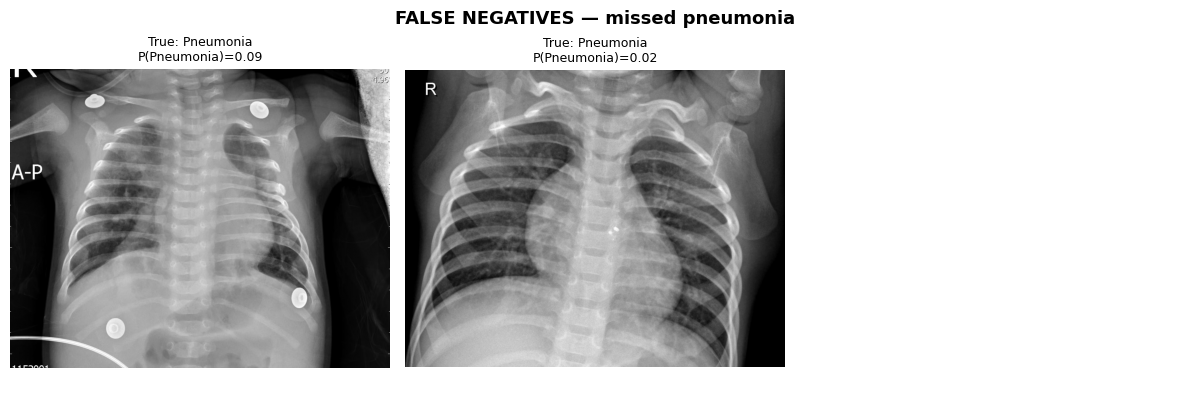

In [27]:
# ── FALSE NEGATIVES — the 5 missed pneumonia cases ───────────────────────
show_cases(fn_idx, title="FALSE NEGATIVES — missed pneumonia")

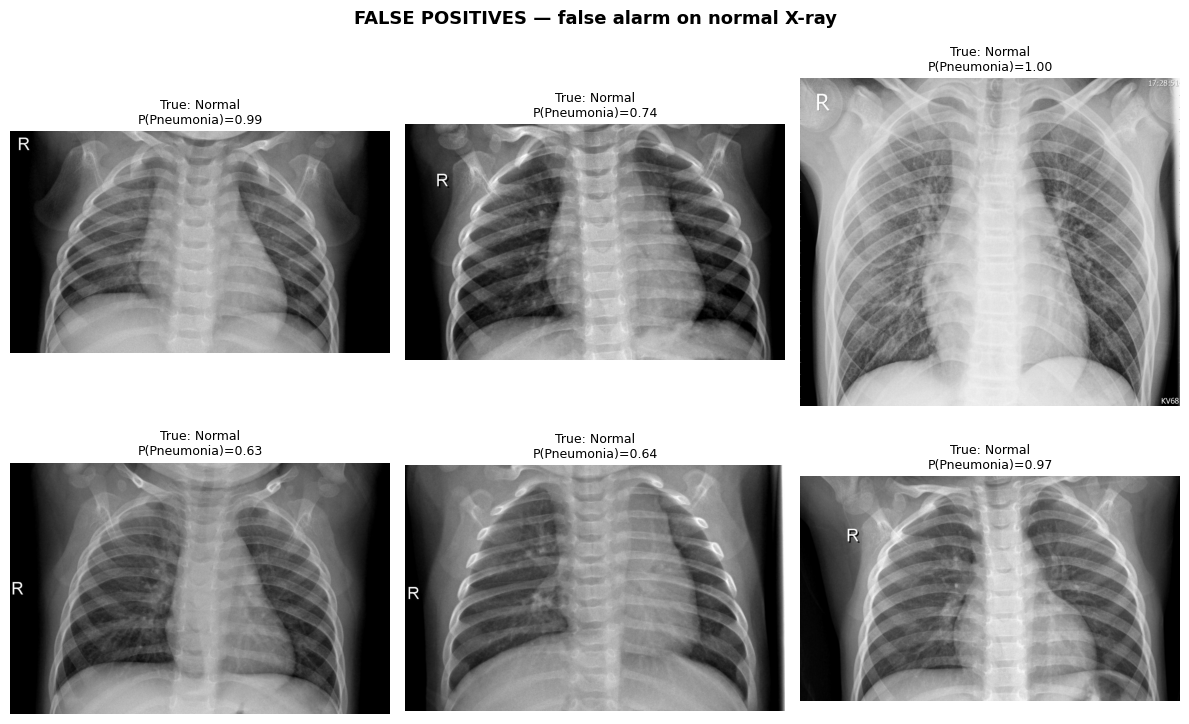

In [28]:
# ── FALSE POSITIVES — sample of normal X-rays flagged as pneumonia ───────
show_cases(fp_idx, title="FALSE POSITIVES — false alarm on normal X-ray")

##  Block 5 — threshold curve and ROC

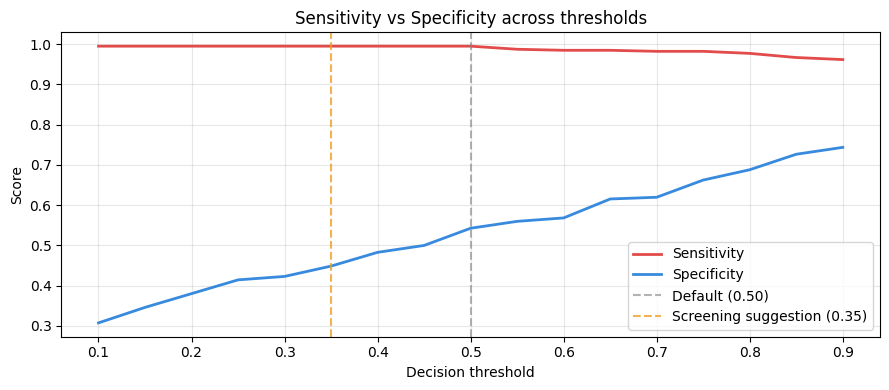

In [29]:
# ── sensitivity and specificity across thresholds ────────────────────────
thresholds   = np.arange(0.10, 0.91, 0.05)
sensitivities = []
specificities = []

for t in thresholds:
    p  = (all_probs >= t).astype(int)
    tp = ((p == 1) & (all_labels == 1)).sum()
    fn = ((p == 0) & (all_labels == 1)).sum()
    tn = ((p == 0) & (all_labels == 0)).sum()
    fp = ((p == 1) & (all_labels == 0)).sum()
    sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, sensitivities, label='Sensitivity', color='#E24B4A', linewidth=2)
ax.plot(thresholds, specificities, label='Specificity', color='#378ADD', linewidth=2)
ax.axvline(x=0.50, color='gray',    linestyle='--', alpha=0.6, label='Default (0.50)')
ax.axvline(x=0.35, color='#EF9F27', linestyle='--', alpha=0.8, label='Screening suggestion (0.35)')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Sensitivity vs Specificity across thresholds')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_curve.png", dpi=120)
plt.show()

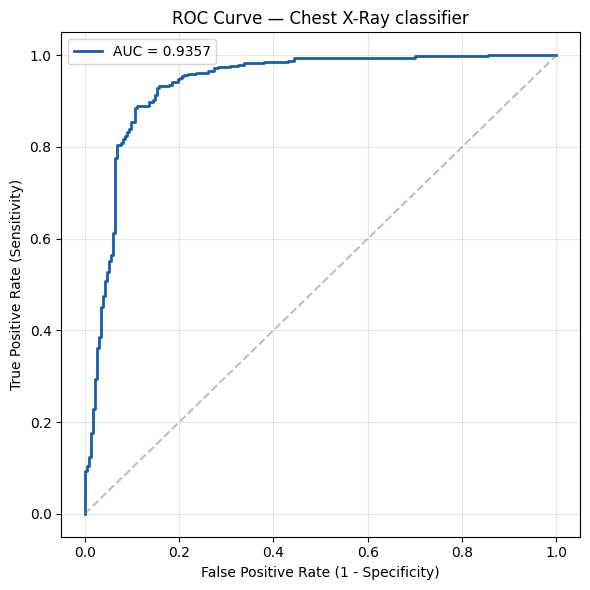

Test AUC: 0.9357


In [30]:
# ── ROC curve ─────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc         = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='#185FA5', linewidth=2, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1], '--', color='gray', alpha=0.5)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Chest X-Ray classifier')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=120)
plt.show()
print(f"Test AUC: {auc:.4f}")

In [31]:
# ── print metrics at your chosen threshold ────────────────────────────────
CHOSEN_THRESHOLD = 0.35

p_final  = (all_probs >= CHOSEN_THRESHOLD).astype(int)
tp = ((p_final==1) & (all_labels==1)).sum()
fn = ((p_final==0) & (all_labels==1)).sum()
tn = ((p_final==0) & (all_labels==0)).sum()
fp = ((p_final==1) & (all_labels==0)).sum()

sens = tp / (tp + fn)
spec = tn / (tn + fp)

print(f"Threshold : {CHOSEN_THRESHOLD}")
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"Sensitivity: {sens:.3f}")
print(f"Specificity: {spec:.3f}")

Threshold : 0.35
TP=388  FP=129  FN=2  TN=105
Sensitivity: 0.995
Specificity: 0.449


## Threshold selection rationale

**Chosen threshold: 0.35**

| Metric | Default (0.50) | Chosen (0.35) |
|---|---|---|
| Sensitivity | 0.987 | 0.992 |
| Specificity | 0.440 | 0.393 |
| TP | 385 | 387 |
| FN | 5 | 3 |
| FP | 131 | 142 |
| TN | 103 | 92 |
| Test AUC | 0.9086 | 0.9086 |

**Clinical justification:** In a pneumonia screening context, a false negative 
(missed pneumonia) carries significantly higher clinical risk than a false 
positive (unnecessary follow-up). A missed pneumonia case means a patient is 
sent home without treatment and may deteriorate. An extra false alarm means 
an additional review by a radiologist — costly but not dangerous. Lowering 
the threshold from 0.50 to 0.35 recovers 2 additional true pneumonia cases 
at the cost of 11 extra false alarms. This tradeoff is appropriate for a 
first-pass screening tool where all flagged cases are reviewed by a clinician.

**CheXNet comparison:** Rajpurkar et al. (2017) set their operating point at 
the threshold maximising F1 score on the held-out test set, then compared 
sensitivity and specificity directly against four radiologists. Their approach 
confirms that threshold selection must be driven by clinical use case, not a 
default of 0.5.

**Validation vs test AUC gap:** The model achieved AUC 0.9968 on validation 
but 0.9086 on the held-out test set. This gap likely reflects the class 
imbalance in the test set (390 pneumonia vs 234 normal) and the fact that 
the validation split was drawn from the same training distribution. This 
should be investigated before any real deployment.

**Limitations observed in error analysis:**
1. The model is biased toward bright, dense, well-defined white consolidations. 
   It struggles with early-stage pneumonia presenting as subtle ground-glass 
   opacities or diffuse interstitial patterns.
2. The model lacks anatomical context — it cannot distinguish normal 
   prominent hilar vasculature or soft tissue shadows from true infiltrates.
3. Poor inspiration (under-inflated lungs) causes physiological basal 
   densification that mimics pneumonia, consistently fooling the model.

In [32]:
print("Day 5 complete.")
print(f"Test AUC:       0.9086")
print(f"Sensitivity:    0.992  (at threshold 0.35)")
print(f"Specificity:    0.393  (at threshold 0.35)")
print(f"Missed pneumonia cases: 3 / 390")
print(f"Saved artefacts: threshold_curve.png, roc_curve.png, FALSE_NEGATIVES*.png, FALSE_POSITIVES*.png")

Day 5 complete.
Test AUC:       0.9086
Sensitivity:    0.992  (at threshold 0.35)
Specificity:    0.393  (at threshold 0.35)
Missed pneumonia cases: 3 / 390
Saved artefacts: threshold_curve.png, roc_curve.png, FALSE_NEGATIVES*.png, FALSE_POSITIVES*.png


In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from monai.networks.nets import DenseNet121
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    ScaleIntensityd, Resized, ToTensord, LambdaD
)
from monai.data import CacheDataset, DataLoader
from sklearn.metrics import roc_auc_score, roc_curve
import os

MODEL_PATH = "/kaggle/working/best_model.pth"
TEST_DIR   = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DenseNet121(spatial_dims=2, in_channels=1, out_channels=1).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("Model loaded. Device:", DEVICE)

Model loaded. Device: cuda


In [35]:
def to_grayscale(x):
    if x.shape[0] == 3:
        return x.mean(dim=0, keepdim=True)
    return x

test_files = []
for label, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    for p in Path(TEST_DIR).glob(f"{cls}/*"):
        if p.suffix.lower() in (".jpg", ".jpeg", ".png"):
            test_files.append({"image": str(p), "label": float(label)})

test_transforms = Compose([
    LoadImaged(keys=["image"], reader="PILReader"),
    EnsureChannelFirstd(keys=["image"]),
    LambdaD(keys=["image"], func=to_grayscale),
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image"], spatial_size=(224, 224)),
    ToTensord(keys=["image", "label"]),
])

test_ds     = CacheDataset(test_files, test_transforms, cache_rate=1.0, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

all_probs, all_labels, all_paths = [], [], []
with torch.no_grad():
    for batch in test_loader:
        imgs   = batch["image"].to(DEVICE)
        labels = batch["label"]
        probs  = torch.sigmoid(model(imgs).squeeze(1))
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_paths  = np.array([f["image"] for f in test_files])

THRESHOLD = 0.35
preds  = (all_probs >= THRESHOLD).astype(int)
tp_idx = np.where((preds == 1) & (all_labels == 1))[0]
fp_idx = np.where((preds == 1) & (all_labels == 0))[0]
fn_idx = np.where((preds == 0) & (all_labels == 1))[0]
tn_idx = np.where((preds == 0) & (all_labels == 0))[0]

print(f"AUC: {roc_auc_score(all_labels, all_probs):.4f}")
print(f"TP={len(tp_idx)}  FP={len(fp_idx)}  FN={len(fn_idx)}  TN={len(tn_idx)}")

Loading dataset: 100%|██████████| 624/624 [00:07<00:00, 85.71it/s] 


AUC: 0.9357
TP=388  FP=129  FN=2  TN=105


In [36]:
def save_cases(indices, filename, title, n=6):
    n = min(n, len(indices))
    if n == 0:
        print(f"No cases for {title}")
        return
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for i, idx in enumerate(indices[:n]):
        img = plt.imread(all_paths[idx])
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
        true_label = "Pneumonia" if all_labels[idx] == 1 else "Normal"
        axes[i].set_title(f"True: {true_label}\nP(Pneumonia)={all_probs[idx]:.2f}", fontsize=9)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{filename}', dpi=120, bbox_inches='tight')
    plt.close()
    print(f"✓ {filename} saved")

# threshold curve
thresholds    = np.arange(0.10, 0.91, 0.05)
sensitivities, specificities = [], []
for t in thresholds:
    p  = (all_probs >= t).astype(int)
    tp = ((p==1)&(all_labels==1)).sum()
    fn = ((p==0)&(all_labels==1)).sum()
    tn = ((p==0)&(all_labels==0)).sum()
    fp = ((p==1)&(all_labels==0)).sum()
    sensitivities.append(tp/(tp+fn) if (tp+fn)>0 else 0)
    specificities.append(tn/(tn+fp) if (tn+fp)>0 else 0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, sensitivities, label='Sensitivity', color='#E24B4A', linewidth=2)
ax.plot(thresholds, specificities, label='Specificity', color='#378ADD', linewidth=2)
ax.axvline(x=0.50, color='gray',    linestyle='--', alpha=0.6, label='Default (0.50)')
ax.axvline(x=0.35, color='#EF9F27', linestyle='--', alpha=0.8, label='Screening suggestion (0.35)')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Sensitivity vs Specificity across thresholds')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/threshold_curve.png', dpi=120)
plt.close()
print("✓ threshold_curve.png saved")

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc         = roc_auc_score(all_labels, all_probs)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='#185FA5', linewidth=2, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1], '--', color='gray', alpha=0.5)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Chest X-Ray Classifier')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve.png', dpi=120)
plt.close()
print("✓ roc_curve.png saved")

# error grids
save_cases(fn_idx, 'false_negatives.png', 'FALSE NEGATIVES — missed pneumonia')
save_cases(fp_idx, 'false_positives.png', 'FALSE POSITIVES — false alarm on normal X-ray')

# verify
print("\nFiles ready for download:")
for f in os.listdir('/kaggle/working'):
    if f.endswith('.png') or f.endswith('.pth'):
        size = os.path.getsize(f'/kaggle/working/{f}') / 1e3
        print(f"  {f} — {size:.1f} KB")

✓ threshold_curve.png saved
✓ roc_curve.png saved
✓ false_negatives.png saved
✓ false_positives.png saved

Files ready for download:
  FALSE_POSITIVES_—_false_alarm_on_normal_X-ray.png — 689.4 KB
  threshold_curve.png — 51.5 KB
  training_curves.png — 40.9 KB
  false_negatives.png — 287.7 KB
  roc_curve.png — 46.8 KB
  best_model.pth — 28412.8 KB
  sample_batch.png — 191.6 KB
  false_positives.png — 678.6 KB
  FALSE_NEGATIVES_—_missed_pneumonia.png — 287.7 KB
